# Car Purchase Amount Prediction Using Regression Models
**Objective**
- This project aims to predict the car purchase amount of customers using demographic and financial variables.

**Problem Type**
- This is a supervised machine learning regression problem because the target variable, `Car Purchase Amount`, is continuous.

**Methods Used**
- Exploratory Data Analysis
- Inferential Statistics
- Linear Regression with Non-Negative Least Squares
- Regression diagnostics
- Model evaluation using MAE, MSE, RMSE, R², and MAPE

# <b>1. Import Libraries<b>

In [193]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, shapiro, ttest_ind
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score,mean_absolute_percentage_error)
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings; warnings.filterwarnings('ignore')
# Visualization style
sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

# Reproducibility
random_state = 42

# <b>2. Load Dataset<b>

In [194]:
df_original = pd.read_csv("Car_Purchasing_Data.csv")
print("Dataset shape:", df_original.shape)
df_original.head()

Dataset shape: (500, 9)


,Customer Name,Customer e-mail,Country,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,USA,0,42,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,USA,0,41,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,USA,1,43,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,USA,1,58,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,USA,1,57,59729.15130,5358.712177,560304.0671,55915.46248


# <b>3. Data Overview<b>

In [195]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer Name        500 non-null    object 
 1   Customer e-mail      500 non-null    object 
 2   Country              500 non-null    object 
 3   Gender               500 non-null    int64  
 4   Age                  500 non-null    int64  
 5   Annual Salary        500 non-null    float64
 6   Credit Card Debt     500 non-null    float64
 7   Net Worth            500 non-null    float64
 8   Car Purchase Amount  500 non-null    float64
dtypes: float64(4), int64(2), object(3)
memory usage: 35.3+ KB


In [196]:
# Check for negative or zero values in numeric columns
print((df_original[['Age','Annual Salary','Net Worth','Car Purchase Amount']] <= 0).any())

Age                    False
Annual Salary          False
Net Worth              False
Car Purchase Amount    False
dtype: bool


In [197]:
# Summary statistics
df_original.drop(['Gender'], axis=1).describe()

,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,46.224000,62127.239608,9607.645049,431475.713625,44209.799218
std,7.990339,11703.378228,3489.187973,173536.756340,10773.178744
min,20.000000,20000.000000,100.000000,20000.000000,9000.000000
25%,41.000000,54391.977195,7397.515792,299824.195900,37629.896040
50%,46.000000,62915.497035,9655.035568,426750.120650,43997.783390
75%,52.000000,70117.862005,11798.867487,557324.478725,51254.709517
max,70.000000,100000.000000,20000.000000,1000000.000000,80000.000000


In [198]:
# Check missing values
missing_values = df_original.isnull().sum()
print("\nMissing values:\n", missing_values)


Missing values:
 Customer Name          0
Customer e-mail        0
Country                0
Gender                 0
Age                    0
Annual Salary          0
Credit Card Debt       0
Net Worth              0
Car Purchase Amount    0
dtype: int64


In [199]:
# Check duplicate rows
duplicate_count = df_original.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


# <b>4. Data Cleaning<b>

In [200]:
# Remove non-predictive identifier variables
columns_to_drop = ["Customer Name", "Customer e-mail", "Country"]
df = df_original.copy()
df = df.drop(columns=columns_to_drop, errors="ignore")
df.head()

,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
0,0,42,62812.09301,11609.380910,238961.2505,35321.45877
1,0,41,66646.89292,9572.957136,530973.9078,45115.52566
2,1,43,53798.55112,11160.355060,638467.1773,42925.70921
3,1,58,79370.03798,14426.164850,548599.0524,67422.36313
4,1,57,59729.15130,5358.712177,560304.0671,55915.46248


# <b>5. Exploratory Data Analysis<b>

## <b>5.1 Target Distribution<b>

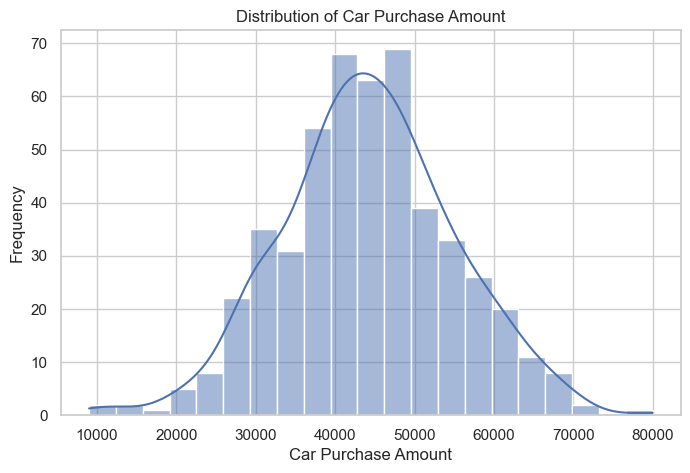

In [201]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Car Purchase Amount"], kde=True)
plt.title("Distribution of Car Purchase Amount")
plt.xlabel("Car Purchase Amount")
plt.ylabel("Frequency")
plt.show()

- `Comment:` This plot shows whether the target variable is normally distributed.

## <b>5.2 Feature Distributions<b>

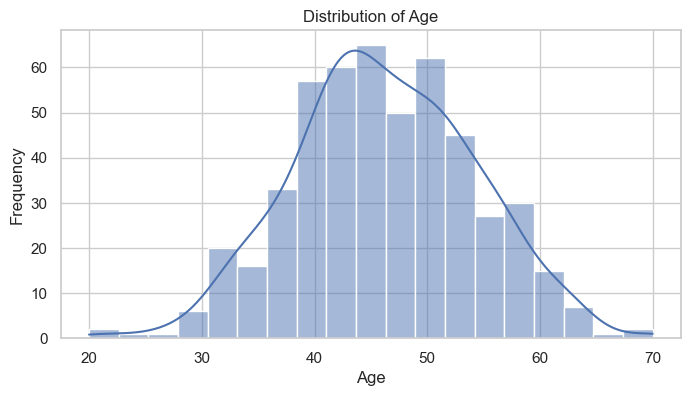

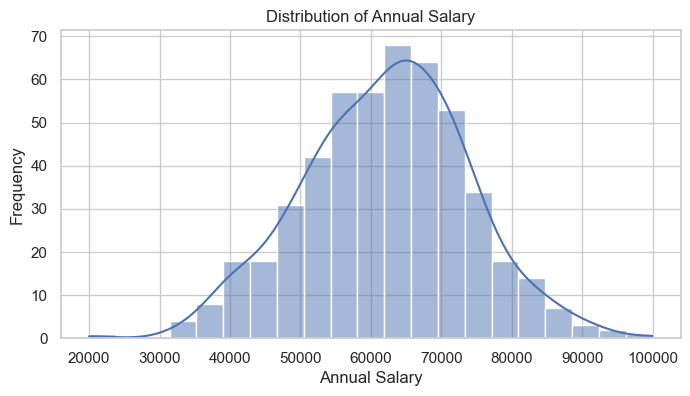

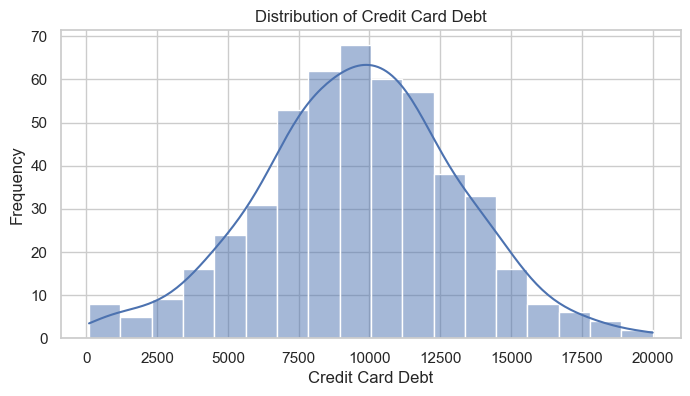

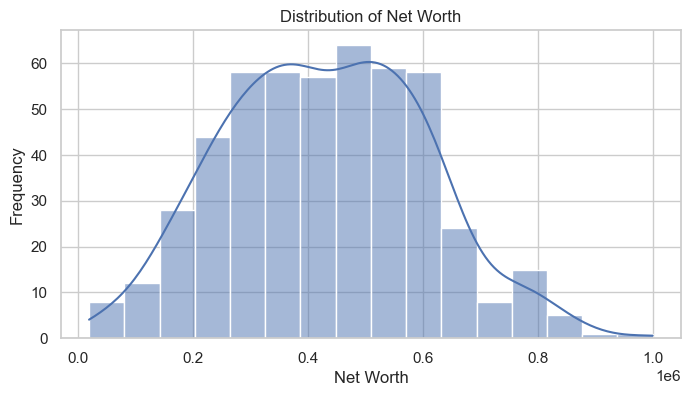

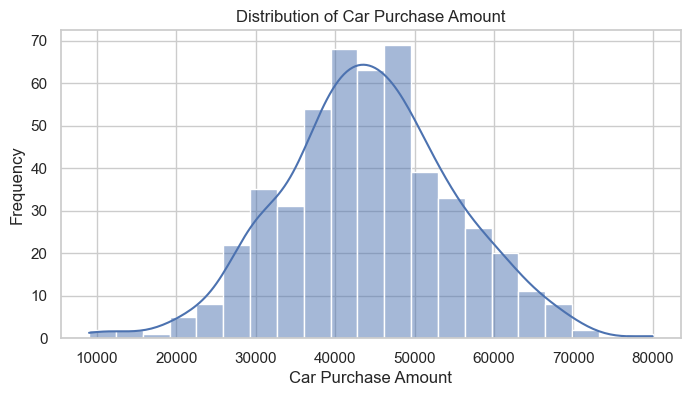

In [202]:
numeric_cols = df.drop('Gender', axis=1)
for col in numeric_cols.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

`Comment:` All numerical feature are approximately normally distributed.

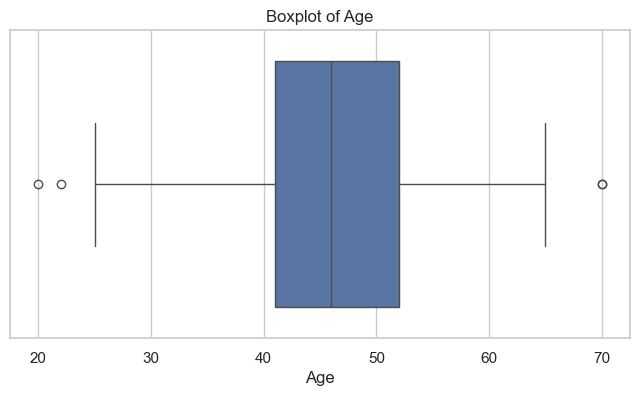

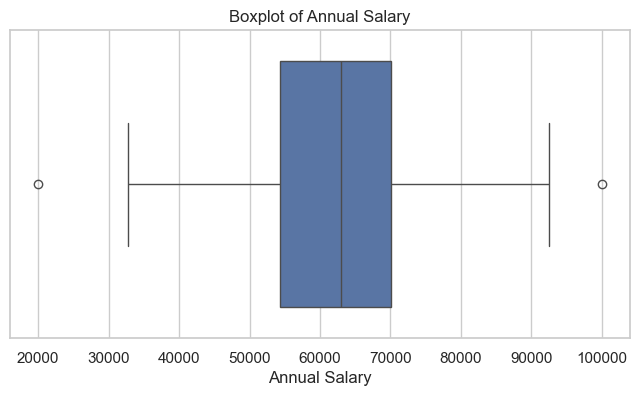

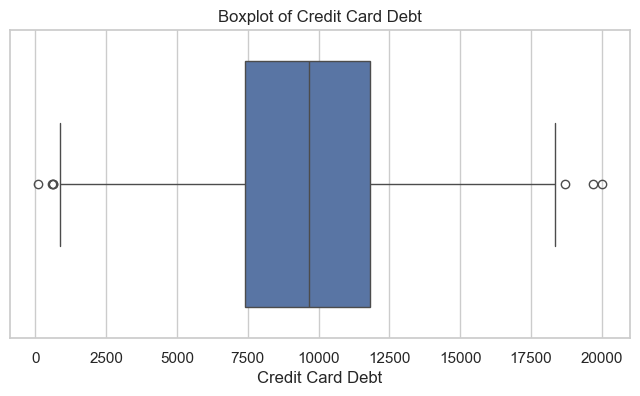

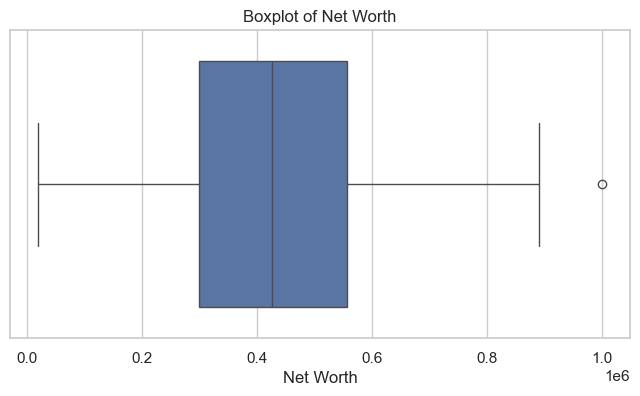

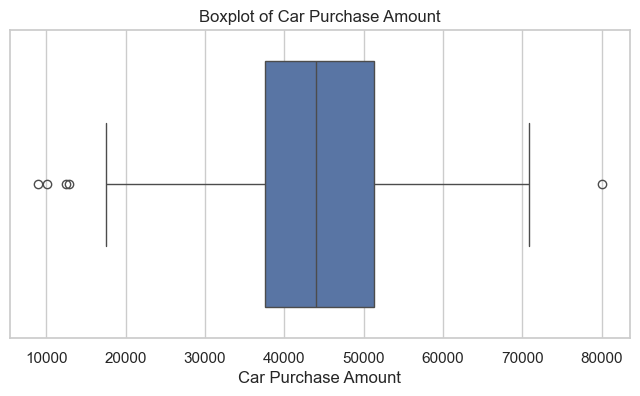

In [203]:
for col in numeric_cols.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

`Comment:` There is few outliers but not much.

## <b>5.3 Bivariate Analysis<b>

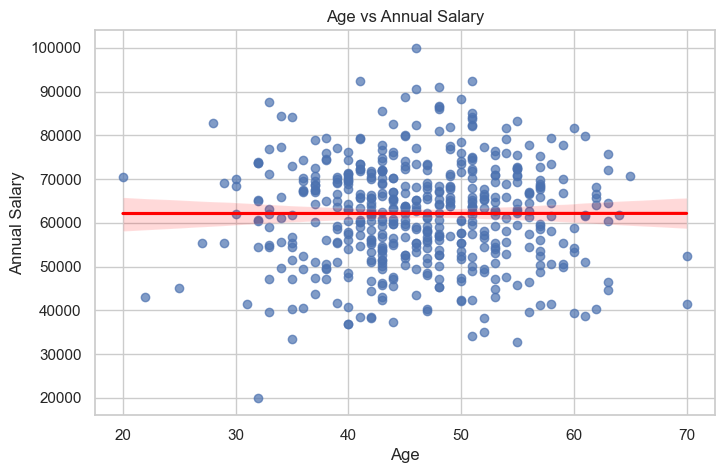

In [204]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x="Age",
    y="Annual Salary",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"}
)
plt.title("Age vs Annual Salary")
plt.xlabel("Age")
plt.ylabel("Annual Salary")
plt.show()

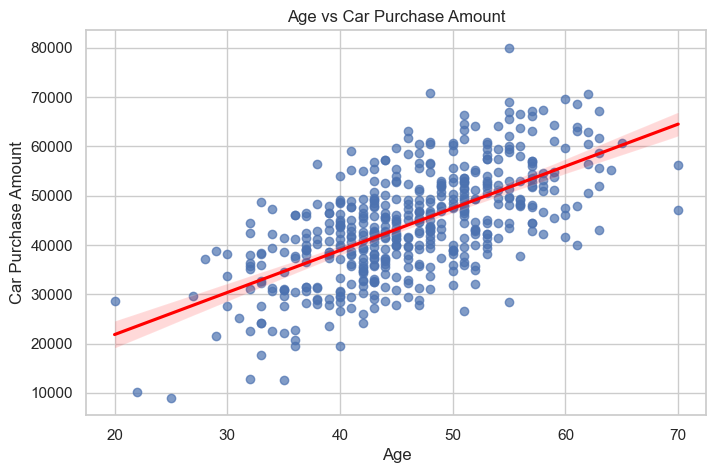

In [205]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x="Age",
    y="Car Purchase Amount",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"}
)
plt.title("Age vs Car Purchase Amount")
plt.xlabel("Age")
plt.ylabel("Car Purchase Amount")
plt.show()

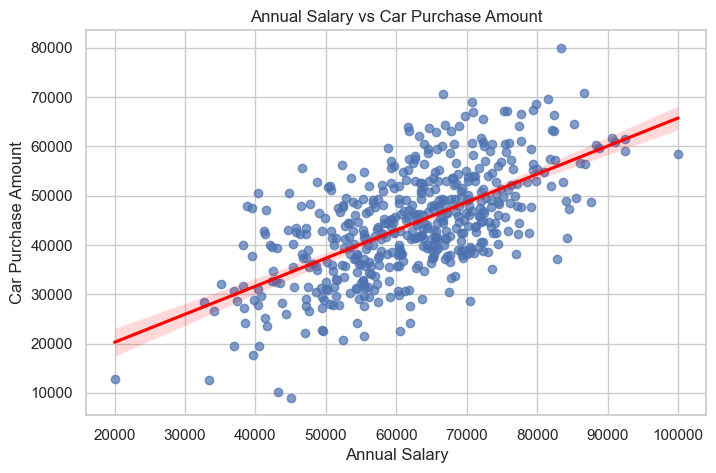

In [206]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x="Annual Salary",
    y="Car Purchase Amount",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"}
)
plt.title("Annual Salary vs Car Purchase Amount")
plt.xlabel("Annual Salary")
plt.ylabel("Car Purchase Amount")
plt.show()

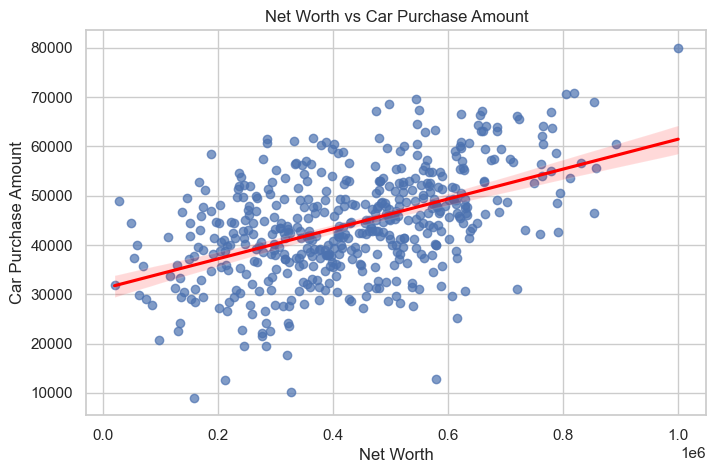

In [207]:
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x="Net Worth",
    y="Car Purchase Amount",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "red"}
)
plt.title("Net Worth vs Car Purchase Amount")
plt.xlabel("Net Worth")
plt.ylabel("Car Purchase Amount")
plt.show()

`Comment:` 
- In 1st figure,the red regression line is almost flat, which indicates that there is little to no strong linear relationship between Age and Annual Salary in this dataset. In other words, annual salary does not appear to increase or decrease substantially as age changes.
- But in rest, there are strong relationship between "Age vs Car Purchase Amount", "Annual Salary vs Car Purchase Amount", "Net Worth vs Car Purchase Amount"

# <b>6. Correlation Analysis<b>

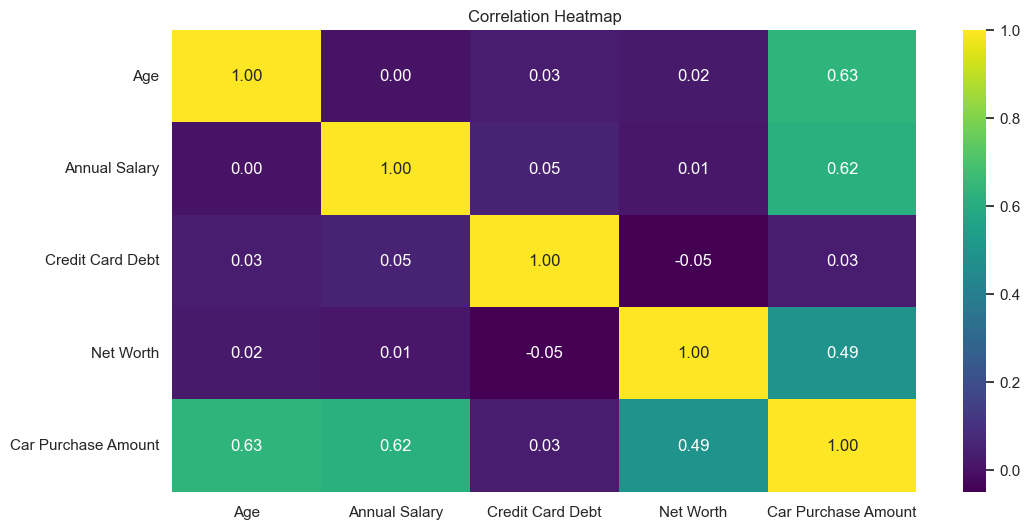

In [208]:
corr_matrix = df.drop('Gender', axis=1).corr()
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap helps identify which variables have strong linear relationships with `Car Purchase Amount`.
Strong predictors are expected to show high positive correlation with the target variable.
Since 'Credit Card Debt' has no significant correlation with 'Car Purchase Amount', so it may not necessary for prediction.

In [209]:
# Pearson correlation tests for all numeric predictors
target = "Car Purchase Amount"

correlation_results = []

for col in df[numeric_cols.columns]:
    if col != target:
        corr, p_value = pearsonr(df[col], df[target])
        correlation_results.append({
            "Feature": col,
            "Correlation": corr,
            "P-value": p_value,
            "Significant at 5%": p_value < 0.05
        })

correlation_results_df = pd.DataFrame(correlation_results)
correlation_results_df.sort_values(by="Correlation", ascending=False)

,Feature,Correlation,P-value,Significant at 5%
0,Age,0.633273,2.105472e-57,True
1,Annual Salary,0.617862,5.756392e-54,True
3,Net Worth,0.488580,2.330089e-31,True
2,Credit Card Debt,0.028882,5.193494e-01,False


# <b>7. Inferential Statistics<b>

## <b>7.1 Gender Difference Test<b>
- Since Gender is binary, test whether average purchase amount differs by gender.

In [210]:
# Independent t-test: Gender and Car Purchase Amount
gender_groups = df["Gender"].unique()
group_0 = df[df["Gender"] == 0]["Car Purchase Amount"]
group_1 = df[df["Gender"] == 1]["Car Purchase Amount"]

t_stat, p_value = ttest_ind(group_0, group_1, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

T-statistic: 1.4866
P-value: 0.137750


`Comment`
- H₀: Mean car purchase amount is equal between gender groups.
- H₁: Mean car purchase amount differs between gender groups.

Since p-value > 0.05, there is evidence of a statistically no significant difference.

## <b>7.2 Normality Test<b>

In [211]:
# Shapiro-Wilk normality test for target variable
stat, p_value = shapiro(df["Car Purchase Amount"])
print(f"Shapiro-Wilk statistic: {stat:.4f}")
print(f"P-value: {p_value:.6f}")

Shapiro-Wilk statistic: 0.9972
P-value: 0.556584


Since p-value > 0.05,then we may conclude that target variable is normally distributed.


# <b>8. Train-Test Split<b>

In [212]:
X= df.drop(columns=["Car Purchase Amount",'Credit Card Debt'], axis=1)
y = df["Car Purchase Amount"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=random_state)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (350, 4)
Testing set: (150, 4)


# <b>9. Feature Scaling<b>

In [213]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# <b>10. Multicollinearity Check using VIF<b>

In [214]:
# Variance Inflation Factor
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]
vif_data.sort_values(by="VIF", ascending=False)
vif_data

,Feature,VIF
0,Gender,1.002753
1,Age,1.002673
2,Annual Salary,1.001966
3,Net Worth,1.001742


`Comment:` Since VIF < 10 , then we may said that there is no multicolinearity.

# <b>11. Model Training<b>

## <b>Linear Regression with NNLS<b>
- Linear Regression with `positive=True` constrains coefficients to be non-negative.
This is useful when predicting non-negative financial quantities such as purchase amount, revenue, or price.

In [215]:
nnls_model = LinearRegression(positive=True)
nnls_model.fit(X_train_scaled, y_train)
y_pred_nnls = nnls_model.predict(X_test_scaled)

# <b>12.Model Evaluation <b>

In [216]:
# Regression evaluation function
def evaluate_regression_model(y_true, y_pred, model_name):
    """
    Evaluate regression model performance.
    """
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2,
        "MAPE": mape
    }

nnls_results = evaluate_regression_model(
    y_test,
    y_pred_nnls,
    "Linear Regression NNLS"
)
results_df = pd.DataFrame([nnls_results])
results_df

,Model,MAE,MSE,RMSE,R2 Score,MAPE
0,Linear Regression NNLS,217.115115,62903.436085,250.805574,0.99941,0.0051


# <b>13. Cross-Validation<b>

In [217]:
# Cross-validation for Linear Regression NNLS
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)

standard_lr = LinearRegression()

cv_scores = cross_val_score(
    standard_lr,
    X_train_scaled,
    y_train,
    cv=cv,
    scoring="r2"
)

print("Cross-validation R2 scores:", cv_scores)
print(f"Mean CV R2: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.8f}")

Cross-validation R2 scores: [0.99944997 0.99962572 0.99944217 0.99950218 0.99949374]
Mean CV R2: 0.9995
Standard deviation: 0.00006581


# <b>14. Actual vs Predicted Plot<b>

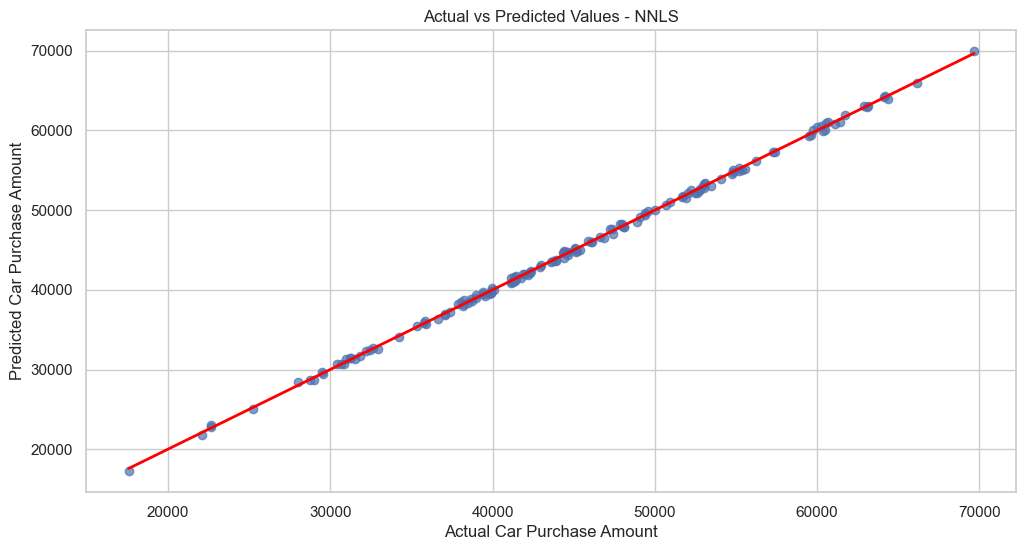

In [218]:
plt.figure(figsize=(12, 6))

plt.scatter(y_test, y_pred_nnls, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Car Purchase Amount")
plt.ylabel("Predicted Car Purchase Amount")
plt.title("Actual vs Predicted Values - NNLS")
plt.show()

`Comment:` Allmost points lie close to the diagonal reference line, indicating that predicted values are close to actual purchase amounts.

# <b>15. Inferential Regression using Statsmodels<b>

In [219]:
# OLS regression using statsmodels for inferential statistics
X_sm = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train.reset_index(drop=True), X_sm.reset_index(drop=True)).fit()
print(ols_model.summary())

                             OLS Regression Results                            
Dep. Variable:     Car Purchase Amount   R-squared:                       1.000
Model:                             OLS   Adj. R-squared:                  1.000
Method:                  Least Squares   F-statistic:                 1.820e+05
Date:                 Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                         15:12:12   Log-Likelihood:                -2411.5
No. Observations:                  350   AIC:                             4833.
Df Residuals:                      345   BIC:                             4852.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          4.382e+04     12.796 

### OLS Regression Interpretation

- The OLS regression model explains a large proportion of the variation in car purchase amount, with an R-squared value of 0.964 and an adjusted R-squared value of 0.964. This indicates strong explanatory power.

- The overall model is statistically significant, as shown by the F-statistic of 2335 and a p-value less than 0.001. This suggests that the predictors jointly explain a significant amount of variation in car purchase amount.

- Among the predictors, Age, Annual Salary, and Net Worth are statistically significant positive predictors of car purchase amount. Their p-values are less than 0.001 and their 95% confidence intervals do not include zero. This means that increases in these financial and demographic variables are associated with higher predicted purchase amounts.

- Gender is not statistically significant, with a p-value of 0.499 and a confidence interval that includes zero. Therefore, Gender does not appear to meaningfully explain car purchase amount in this model.

- The Durbin-Watson statistic is 1.889, suggesting no serious autocorrelation in the residuals. The condition number is 1.07, indicating no major multicollinearity problem. However, the Omnibus and Jarque-Bera tests suggest that the residuals are not normally distributed, so additional residual diagnostic plots should be examined.

# <b>16. Homoscedasticity Test: Breusch-Pagan<b>

In [220]:
# Breusch-Pagan test for heteroscedasticity

bp_test = het_breuschpagan(ols_model.resid,ols_model.model.exog)

bp_results = pd.Series(bp_test,
    index=["Lagrange multiplier statistic", "p-value", "f-value", "f p-value"])
bp_results

Lagrange multiplier statistic    3.998654
p-value                          0.406188
f-value                          0.996770
f p-value                        0.409307
dtype: float64

- The Breusch–Pagan test indicates evidence of heteroscedasticity in the model. Since the p-value is extremely small (p < 0.001), the assumption of constant residual variance is violated.

In [221]:
'''Because the Breusch–Pagan test indicated heteroscedasticity,
robust standard errors were used to obtain more reliable inference.'''
# Fit OLS model with robust standard errors
ols_model_robust = ols_model.get_robustcov_results(cov_type="HC3")
print(ols_model_robust.summary())

                             OLS Regression Results                            
Dep. Variable:     Car Purchase Amount   R-squared:                       1.000
Model:                             OLS   Adj. R-squared:                  1.000
Method:                  Least Squares   F-statistic:                 2.117e+05
Date:                 Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                         15:12:12   Log-Likelihood:                -2411.5
No. Observations:                  350   AIC:                             4833.
Df Residuals:                      345   BIC:                             4852.
Df Model:                            4                                         
Covariance Type:                   HC3                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          4.382e+04     12.879 

In [222]:
# Breusch-Pagan test for heteroscedasticity in robust model

bp_test = het_breuschpagan(ols_model_robust.resid,ols_model_robust.model.exog)

bp_results = pd.Series(bp_test,
    index=["Lagrange multiplier statistic", "p-value", "f-value", "f p-value"])
bp_results

Lagrange multiplier statistic    3.998654
p-value                          0.406188
f-value                          0.996770
f p-value                        0.409307
dtype: float64

- For the robust model, the Breusch–Pagan test produced a p-value of 0.406, which is greater than 0.05. Therefore, we fail to reject the null hypothesis of constant residual variance. This indicates that heteroscedasticity is no longer statistically significant in the robust model.

# <b>17. Coefficient Interpretation<b>

In [223]:
# NNLS coefficients
coef_df = pd.DataFrame({"Feature": X.columns,"Coefficient": nnls_model.coef_})
coef_df.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
2,Annual Salary,6764.456485
1,Age,6718.119108
3,Net Worth,5138.259410
0,Gender,18.718483


# <b>18. Prediction Error Table<b>

In [228]:
prediction_results = pd.DataFrame({
    "Actual Value": y_test.values,
    "Predicted Value": y_pred_nnls,
    "Residual": y_test.values - y_pred_nnls,
    "Absolute Error": np.abs(y_test.values - y_pred_nnls)
})

# Display summary statistics of prediction results
prediction_results.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Actual Value,150.0,45119.14,10364.37,17584.57,38696.77,44433.72,52673.57,69669.47
Predicted Value,150.0,45088.76,10349.43,17237.78,38722.17,44653.53,52448.26,69936.78
Residual,150.0,30.37,249.79,-428.12,-199.69,60.83,244.53,458.98
Absolute Error,150.0,217.12,125.98,4.94,107.89,226.59,315.75,458.98


`Comments:`
- The prediction summary table compares actual car purchase amounts with model-predicted values for 150 test observations.

- The mean actual value is 45,119.14, while the mean predicted value is 45,088.76. These two values are very close, suggesting that the model has little overall prediction bias.

- The mean residual is 30.37, which is close to zero. This indicates that the model does not systematically overpredict or underpredict car purchase amount.

- The mean absolute error is 217.12, meaning that on average, model predictions differ from actual values by approximately 217 units. Considering that the average purchase amount is over 45,000, this prediction error is relatively small.

- Overall, the model demonstrates strong predictive accuracy on the test dataset.

# <b> 19. `Limitations`
- The dataset appears very clean, which may not reflect real-world noise.
- Very high R² may suggest strong linear structure or synthetic data.
- External variables such as car brand preference, location, family size, loan eligibility, and market conditions were not included.
<b>